In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    mean_squared_error, r2_score, ConfusionMatrixDisplay
)
from sklearn.tree import DecisionTreeClassifier, plot_tree cv

In [2]:
df_raw = pd.read_csv('Churn_Dataset.csv')

print('Shape    :', df_raw.shape)
print('Columns  :', df_raw.columns.tolist())
df_raw.head()

Shape    : (7043, 23)
Columns  : ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'numAdminTickets', 'numTechTickets', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.5,0,0,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,0,0,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,3,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,0,0,Yes


In [3]:
print('=== Data Types ===')
print(df_raw.dtypes)
print('\n=== Missing Values ===')
print(df_raw.isnull().sum())

=== Data Types ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
numAdminTickets       int64
numTechTickets        int64
Churn                object
dtype: object

=== Missing Values ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV  

In [4]:
print('=== Basic Statistics ===')
df_raw.describe(include='all')

=== Basic Statistics ===


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043.000000,7043,7043.000000,7043.000000,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,2,4,NaN,6531,NaN,NaN,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,NaN,,NaN,NaN,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,2810,2785,3875,4171,2365,NaN,11,NaN,NaN,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,0.515689,0.419566,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,1.275299,1.250117,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,0.000000,0.000000,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,0.000000,0.000000,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,0.000000,0.000000,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,0.000000,0.000000,NaN


In [5]:
df = df_raw.copy()

# Fix TotalCharges — stored as object, convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill NaN in TotalCharges (new customers with tenure=0)
df['TotalCharges'].fillna(df['MonthlyCharges'], inplace=True)

# Drop customerID
df.drop('customerID', axis=1, inplace=True)

# Strip whitespace from string columns
str_cols = df.select_dtypes('object').columns
df[str_cols] = df[str_cols].apply(lambda x: x.str.strip())

# Map SeniorCitizen 0/1 → No/Yes
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# Standardise service columns
service_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in service_cols:
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

# Create tenure groups
df['TenureGroup'] = pd.cut(df['tenure'], bins=[0,12,24,36,48,60,72],
                            labels=['0-12m','13-24m','25-36m','37-48m','49-60m','61-72m'])

# Create MonthlyCharges category
df['ChargesCategory'] = pd.cut(df['MonthlyCharges'], bins=3,
                                labels=['Low','Medium','High'])

print('✅ Transformation complete!')
print('Shape after cleaning:', df.shape)
print('Null values remaining:', df.isnull().sum().sum())
df.head()

✅ Transformation complete!
Shape after cleaning: (7043, 24)
Null values remaining: 11


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets,Churn,TenureGroup,ChargesCategory
0,Female,No,Yes,No,1,No,No,DSL,No,Yes,...,Month-to-month,Yes,Electronic check,29.85,29.85,0,0,No,0-12m,Low
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,...,One year,No,Mailed check,56.95,1889.50,0,0,No,25-36m,Medium
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,0,0,Yes,0-12m,Medium
3,Male,No,No,No,45,No,No,DSL,Yes,No,...,One year,No,Bank transfer (automatic),42.30,1840.75,0,3,No,37-48m,Low
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,0,0,Yes,0-12m,Medium


In [6]:
df_encoded = df.copy()
df_encoded.drop(['TenureGroup', 'ChargesCategory'], axis=1, inplace=True)

le = LabelEncoder()
cat_cols = df_encoded.select_dtypes('object').columns.tolist()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print('✅ Encoding complete!')
print('Encoded columns:', cat_cols)
print('\nChurn distribution (0=No, 1=Yes):')
print(df_encoded['Churn'].value_counts())
df_encoded.head()

✅ Encoding complete!
Encoded columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

Churn distribution (0=No, 1=Yes):
Churn
0    5174
1    1869
Name: count, dtype: int64


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets,Churn
0,0,0,1,0,1,0,0,0,0,1,...,0,0,0,1,2,29.85,29.85,0,0,0
1,1,0,0,0,34,1,0,0,1,0,...,0,0,1,0,3,56.95,1889.50,0,0,0
2,1,0,0,0,2,1,0,0,1,1,...,0,0,0,1,3,53.85,108.15,0,0,1
3,1,0,0,0,45,0,0,0,1,0,...,0,0,1,0,0,42.30,1840.75,0,3,0
4,0,0,0,0,2,1,0,1,0,0,...,0,0,0,1,2,70.70,151.65,0,0,1


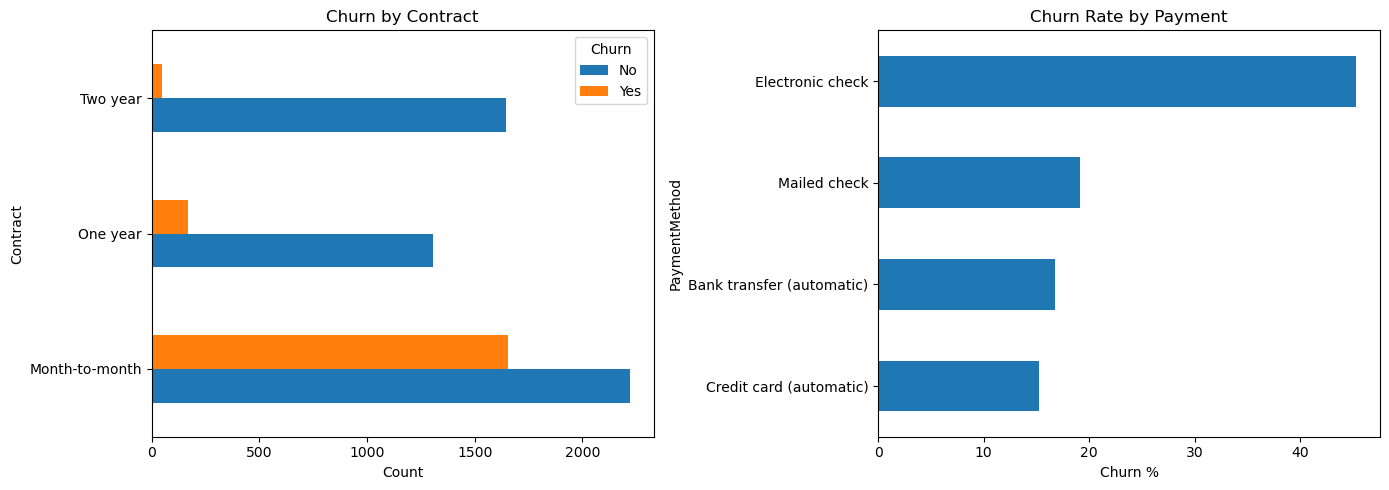

Month-to-month & electronic check users churn more.


In [35]:

# Create subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# --- 1. Churn by Contract ---
df.groupby(['Contract', 'Churn']).size().unstack().plot(
    kind='barh', ax=ax[0]
)
ax[0].set_title('Churn by Contract')
ax[0].set_ylabel('Contract')
ax[0].set_xlabel('Count')

# --- 2. Churn Rate by Payment Method ---
(df.groupby('PaymentMethod')['Churn']
   .apply(lambda x: (x == 'Yes').mean() * 100)
   .sort_values()
).plot(kind='barh', ax=ax[1])

ax[1].set_title('Churn Rate by Payment')
ax[1].set_xlabel('Churn %')

# Show plot
plt.tight_layout()
plt.show()

print("Month-to-month & electronic check users churn more.")

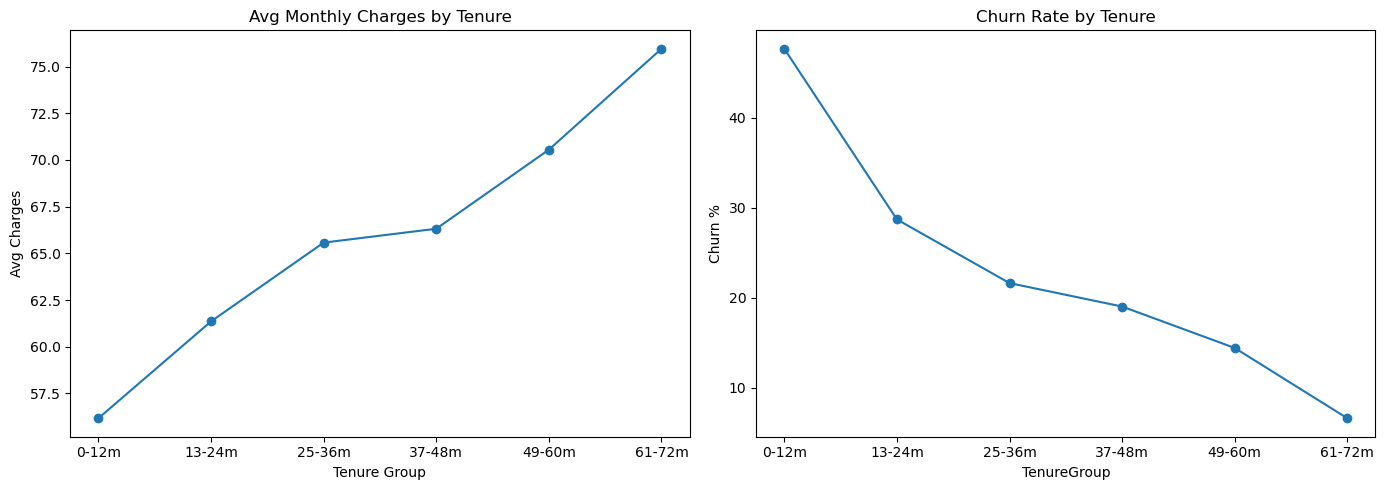

Churn is highest in early tenure and decreases over time.


In [8]:

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# --- 1. Avg Monthly Charges by Tenure ---
df.groupby('TenureGroup')['MonthlyCharges'].mean().plot(
    kind='line', marker='o', ax=ax[0]
)
ax[0].set_title('Avg Monthly Charges by Tenure')
ax[0].set_xlabel('Tenure Group')
ax[0].set_ylabel('Avg Charges')

# --- 2. Churn Rate by Tenure ---
(df.groupby('TenureGroup')['Churn']
   .apply(lambda x: (x == 'Yes').mean() * 100)
).plot(kind='line', marker='o', ax=ax[1])

ax[1].set_title('Churn Rate by Tenure')
ax[1].set_ylabel('Churn %')

plt.tight_layout()
plt.show()

print("Churn is highest in early tenure and decreases over time.")

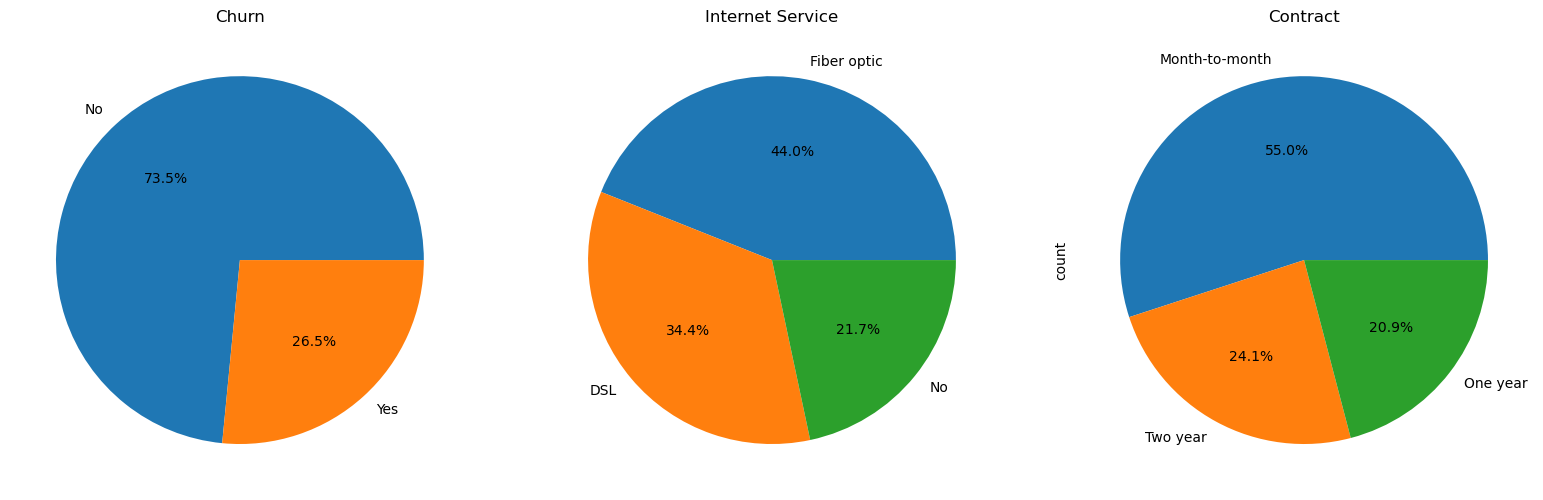

Churn ~26%, Fiber users high, many on month-to-month.


In [9]:

fig, ax = plt.subplots(1, 3, figsize=(16, 5))

# --- 1. Churn Distribution ---
df['Churn'].value_counts().plot.pie(
    autopct='%1.1f%%', ax=ax[0]
)
ax[0].set_title('Churn')
ax[0].set_ylabel('')

# --- 2. Internet Service ---
df['InternetService'].value_counts().plot.pie(
    autopct='%1.1f%%', ax=ax[1]
)
ax[1].set_title('Internet Service')
ax[1].set_ylabel('')

# --- 3. Contract Type ---
df['Contract'].value_counts().plot.pie(
    autopct='%1.1f%%', ax=ax[2]
)
ax[2].set_title('Contract')

plt.tight_layout()
plt.show()

print("Churn ~26%, Fiber users high, many on month-to-month.")

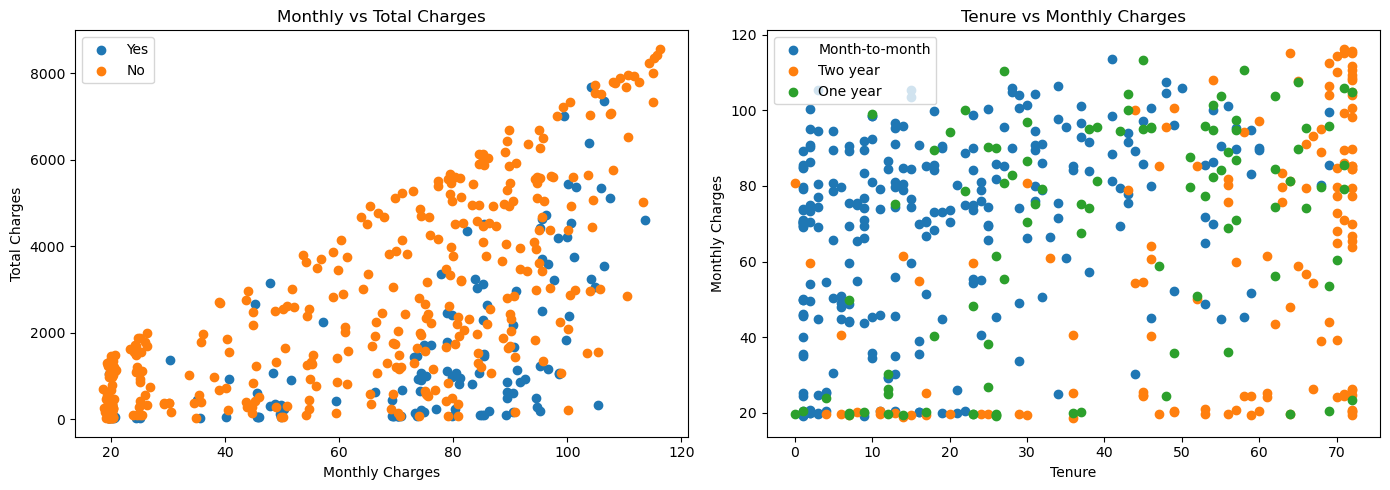

In [10]:

df_small = df.sample(500)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# --- 1. Monthly vs Total Charges ---
for label in df_small['Churn'].unique():
    subset = df_small[df_small['Churn'] == label]
    ax[0].scatter(subset['MonthlyCharges'], subset['TotalCharges'], label=label)

ax[0].set_title('Monthly vs Total Charges')
ax[0].legend()
ax[0].set_xlabel('Monthly Charges')
ax[0].set_ylabel('Total Charges')

# --- 2. Tenure vs Monthly Charges ---
for contract in df_small['Contract'].unique():
    subset = df_small[df_small['Contract'] == contract]
    ax[1].scatter(subset['tenure'], subset['MonthlyCharges'], label=contract)

ax[1].set_title('Tenure vs Monthly Charges')
ax[1].legend()
ax[1].set_ylabel('Monthly Charges')
ax[1].set_xlabel('Tenure')

plt.tight_layout()
plt.show()

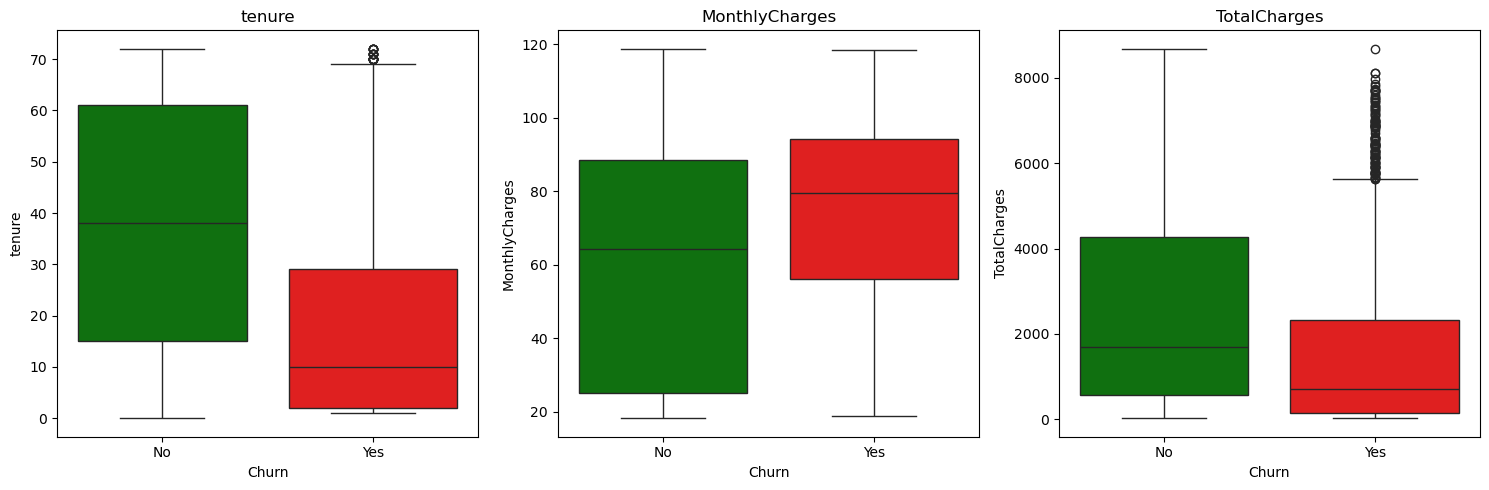

Churn customers have lower tenure, higher monthly charges, and lower total charges.


In [11]:

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Color for Churn (No = green, Yes = red)
palette = {'No': 'green', 'Yes': 'red'}

for i, col in enumerate(cols):
    sns.boxplot(data=df, x='Churn', y=col, ax=ax[i], palette=palette)
    ax[i].set_title(col)

plt.tight_layout()
plt.show()

print("Churn customers have lower tenure, higher monthly charges, and lower total charges.")

In [12]:

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Scale features
X = StandardScaler().fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", len(X_train), "| Test:", len(X_test))
print("Churn ratio (train):", round(y_train.mean(), 2))
print("Churn ratio (test):", round(y_test.mean(), 2))

Train: 5634 | Test: 1409
Churn ratio (train): 0.27
Churn ratio (test): 0.27


In [13]:

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print(classification_report(y_test, y_pred))

Accuracy: 0.8595
              precision    recall  f1-score   support

           0       0.89      0.92      0.91      1035
           1       0.76      0.69      0.72       374

    accuracy                           0.86      1409
   macro avg       0.83      0.81      0.81      1409
weighted avg       0.86      0.86      0.86      1409



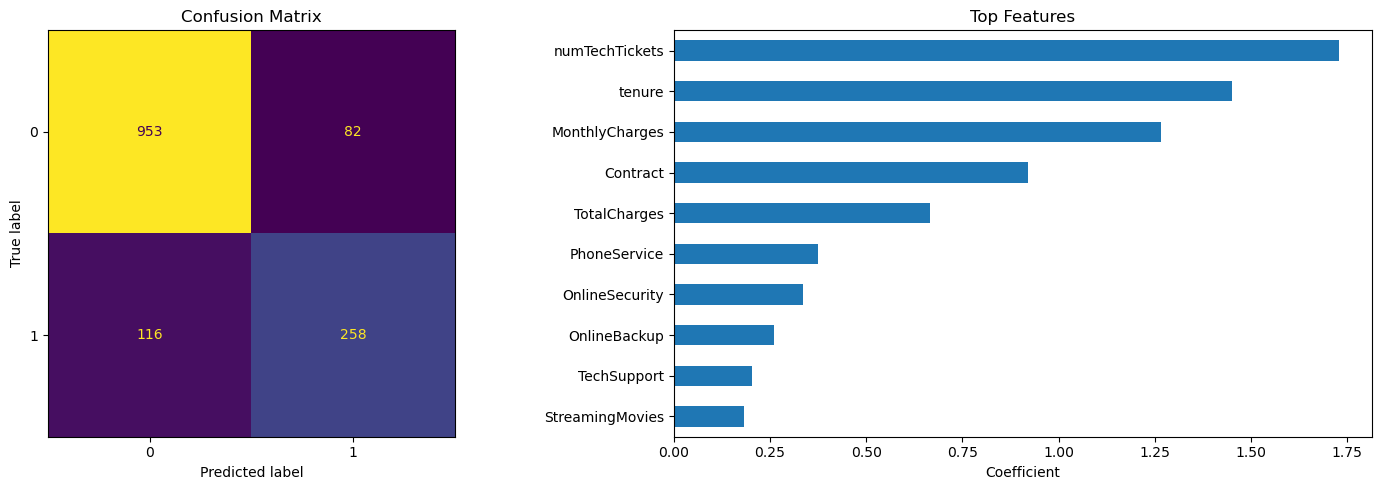

In [14]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]  # ← THIS LINE WAS MISSING

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# --- 1. Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(ax=ax[0], colorbar=False)
ax[0].set_title('Confusion Matrix')



# --- 3. Feature Importance ---
feat = abs(lr.coef_[0])
pd.Series(feat, index=df_encoded.drop('Churn', axis=1).columns) \
  .sort_values().tail(10).plot(kind='barh', ax=ax[1])
ax[1].set_title('Top Features')
ax[1].set_xlabel('Coefficient')

plt.tight_layout()
plt.show()

In [15]:

# Features & target
X = df_encoded.drop(['Churn', 'MonthlyCharges', 'TotalCharges'], axis=1)
y = df_encoded['MonthlyCharges']

# Scale
X = StandardScaler().fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 4))
print("R2:", round(r2_score(y_test, y_pred), 4))

RMSE: 13.321
R2: 0.8004


In [26]:

# Features & target
X = df_encoded.drop('InternetService', axis=1)
y = df_encoded['InternetService']

# Scale
X = StandardScaler().fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Find best K
scores = []
for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    scores.append(accuracy_score(y_test, model.predict(X_test)))

best_k = np.argmax(scores) + 1
print("Best K:", best_k)

# Final model
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))

Best K: 11
              precision    recall  f1-score   support

           0       0.85      0.74      0.79       463
           1       0.86      0.90      0.88       631
           2       0.91      0.99      0.95       315

    accuracy                           0.87      1409
   macro avg       0.87      0.88      0.87      1409
weighted avg       0.87      0.87      0.86      1409



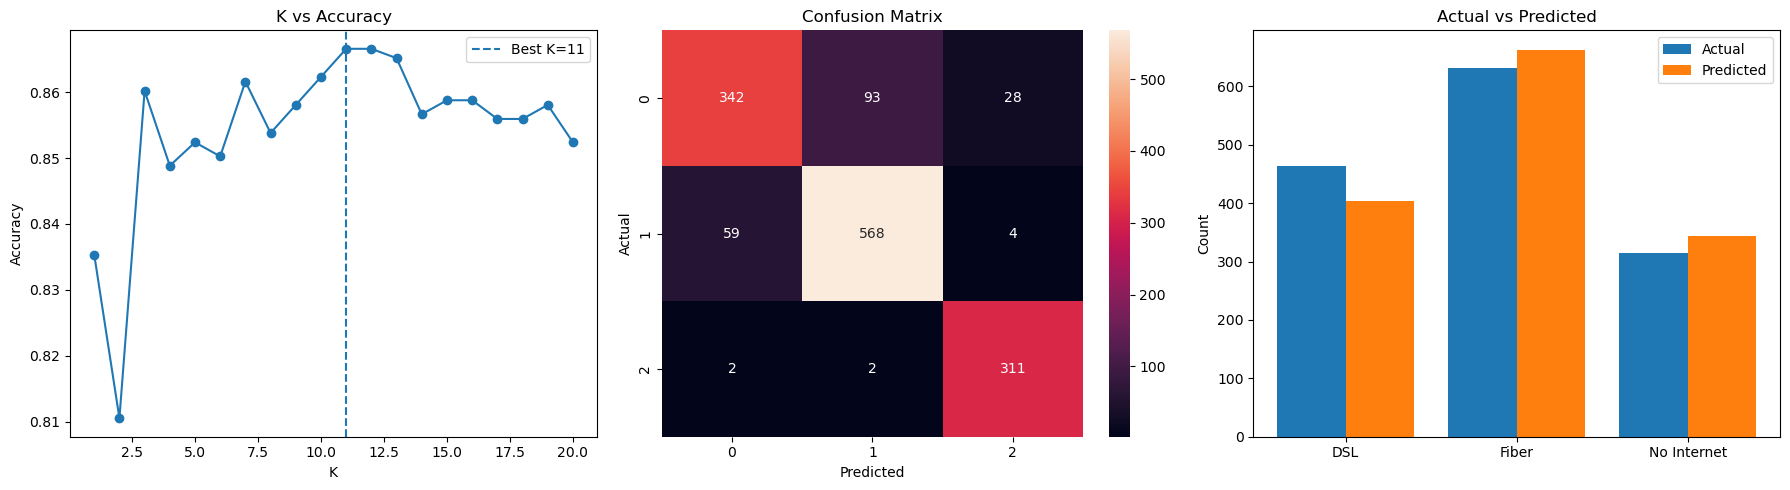

In [27]:
from collections import Counter
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 1. K vs Accuracy ---
axes[0].plot(range(1, 21), scores, marker='o')
axes[0].axvline(best_k, linestyle='--', label=f'Best K={best_k}')
axes[0].set_title('K vs Accuracy')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# --- 2. Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[1])
axes[1].set_title('Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# --- 3. Actual vs Predicted Count ---
true = Counter(y_test)
pred = Counter(y_pred)

classes = [0, 1, 2]
x = np.arange(len(classes))

axes[2].bar(x - 0.2, [true.get(i,0) for i in classes], 0.4, label='Actual')
axes[2].bar(x + 0.2, [pred.get(i,0) for i in classes], 0.4, label='Predicted')

axes[2].set_xticks(x)
axes[2].set_xticklabels(['DSL','Fiber','No Internet'])
axes[2].set_title('Actual vs Predicted')
axes[2].legend()
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [28]:

# Features
cols = ['tenure', 'MonthlyCharges', 'TotalCharges',
        'numAdminTickets', 'numTechTickets']

X = df_encoded[cols]

# Scale
X = StandardScaler().fit_transform(X)

# Elbow method
inertia = []
for k in range(2, 11):
    model = KMeans(n_clusters=k, n_init=10)
    model.fit(X)
    inertia.append(model.inertia_)

# Final model
kmeans = KMeans(n_clusters=4, n_init=10)
df['Cluster'] = kmeans.fit_predict(X)

# Results
print(df['Cluster'].value_counts())
print(df.groupby('Cluster')[cols].mean().round(2))

Cluster
1    4048
0    1772
2     735
3     488
Name: count, dtype: int64
         tenure  MonthlyCharges  TotalCharges  numAdminTickets  numTechTickets
Cluster                                                                       
0         58.01           88.66       5129.34             0.20            0.08
1         19.50           51.79        837.99             0.08            0.11
2         28.59           62.08       1796.26             3.80            0.19
3         51.70           89.64       4620.91             0.35            4.54


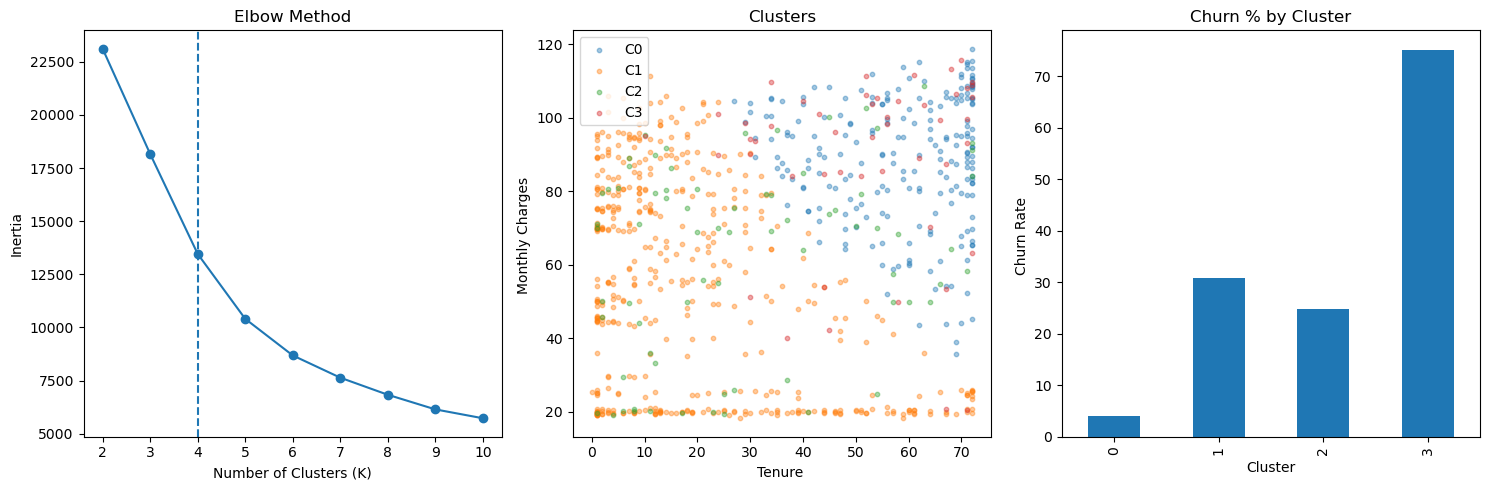

In [29]:

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# --- 1. Elbow Method ---
ax[0].plot(range(2,11), inertia, marker='o')
ax[0].axvline(4, linestyle='--')
ax[0].set_title('Elbow Method')
ax[0].set_xlabel('Number of Clusters (K)')
ax[0].set_ylabel('Inertia')

# --- 2. Scatter (Reduced Points) ---
df_sample = df.sample(800)   # reduce bubbles

for c in range(4):
    temp = df_sample[df_sample['Cluster'] == c]
    ax[1].scatter(temp['tenure'], temp['MonthlyCharges'],
                  s=10, alpha=0.4, label=f'C{c}')

ax[1].set_title('Clusters')
ax[1].set_xlabel('Tenure')
ax[1].set_ylabel('Monthly Charges')
ax[1].legend()
ax[1].set_xlabel('Tenure ')
ax[1].set_ylabel('Monthly Charges ')

# --- 3. Churn per Cluster ---
(df.groupby('Cluster')['Churn']
   .apply(lambda x: (x=='Yes').mean()*100)
).plot(kind='bar', ax=ax[2])

ax[2].set_title('Churn % by Cluster')
ax[2].set_xlabel('Cluster')
ax[2].set_ylabel('Churn Rate ')

plt.tight_layout()
plt.show()

In [30]:

# --- Model ---
model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print(classification_report(y_test, y_pred))

Accuracy: 0.9808
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       463
           1       0.97      0.98      0.98       631
           2       1.00      1.00      1.00       315

    accuracy                           0.98      1409
   macro avg       0.98      0.98      0.98      1409
weighted avg       0.98      0.98      0.98      1409



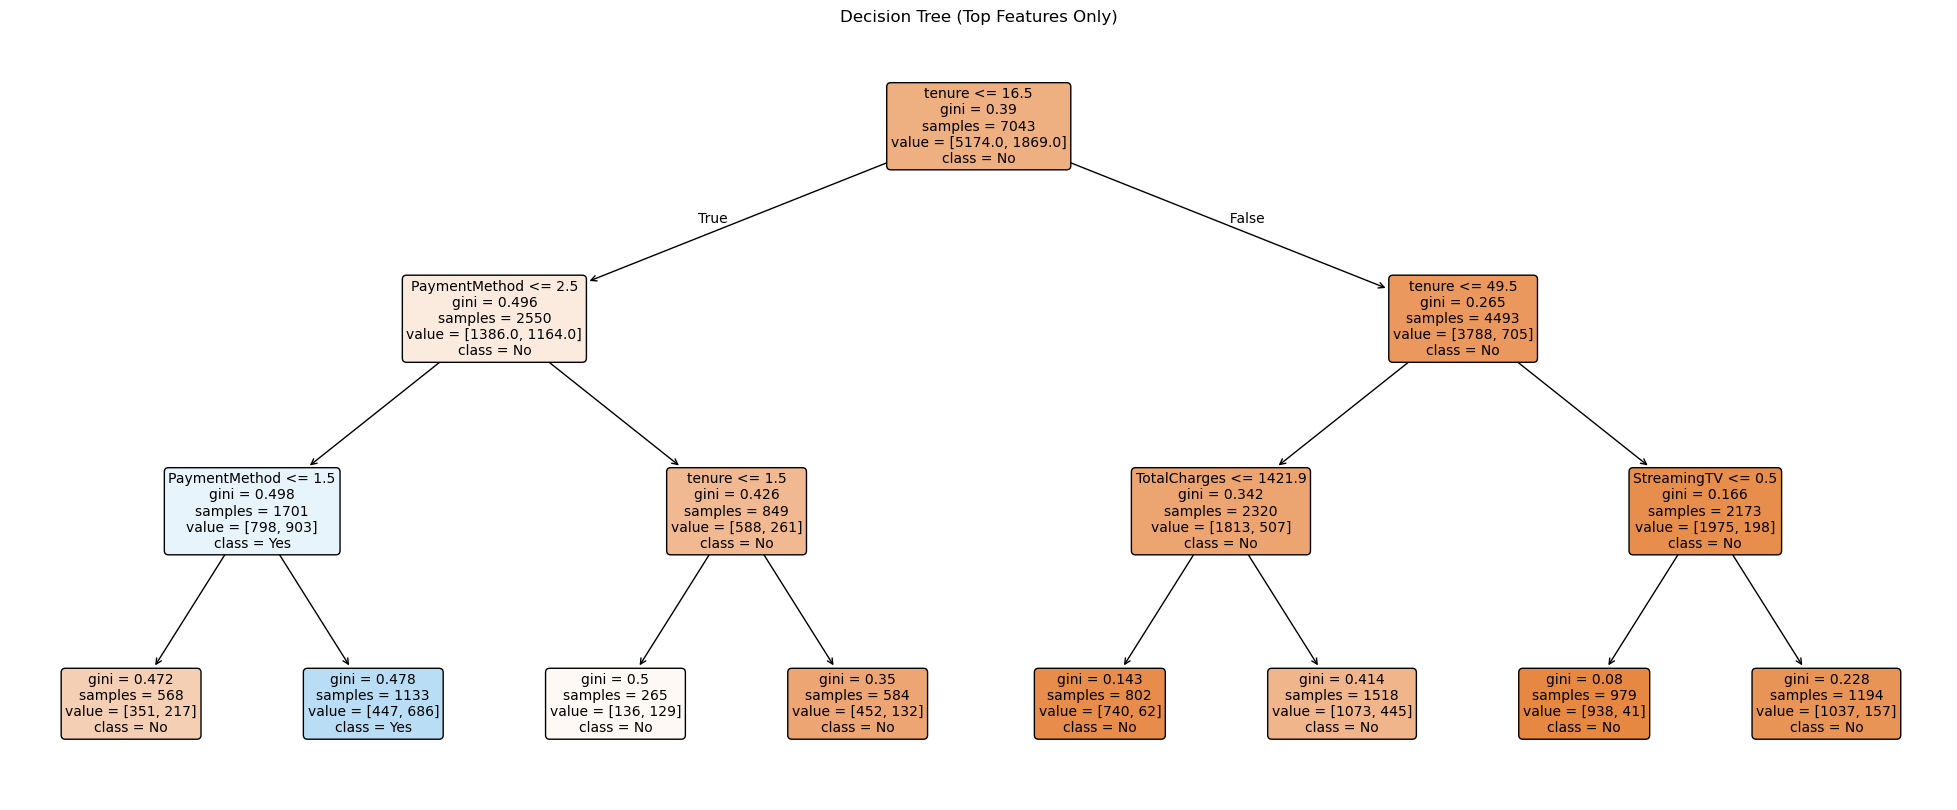

In [32]:

# --- Get top 10 important features ---
feat_imp = pd.Series(model.feature_importances_,
                     index=df_encoded.drop('Churn', axis=1).columns)

top_features = feat_imp.sort_values(ascending=False).head(10).index

# --- Create new dataset with only top features ---
X_top = df_encoded[top_features]
y = df_encoded['Churn']

# --- Train new model ---
dt_top = DecisionTreeClassifier(max_depth=3)
dt_top.fit(X_top, y)

# --- Plot tree ---
plt.figure(figsize=(25, 10))

plot_tree(
    dt_top,
    feature_names=top_features,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree (Top Features Only)")
plt.show()